In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("./public/creditcard.csv")[:80000]

In [12]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,58284.0,1.216664,0.249684,0.174210,0.510376,-0.179497,-0.560982,-0.021601,-0.028357,-0.179274,...,-0.253330,-0.797699,0.069440,-0.041220,0.220108,0.096814,-0.030399,0.018715,11.99,0
79996,58284.0,-0.690760,1.331928,0.913395,0.111679,-0.344744,-1.041187,0.340727,0.379708,-0.492570,...,-0.223222,-0.739941,0.060943,0.319461,-0.150171,0.075715,0.115052,0.034766,9.99,0
79997,58285.0,-2.287270,1.121568,1.163585,0.948471,-1.490482,1.046850,-0.699580,1.584645,-0.717062,...,0.243795,0.398433,-0.048050,-0.282601,0.233288,-0.252045,-0.409044,-0.253114,102.08,0
79998,58286.0,-1.350941,0.233411,0.950824,1.023505,0.415847,-0.505863,0.711381,-0.070386,-0.193938,...,0.026327,0.595887,0.461400,0.066594,-0.158632,-0.273392,0.350422,0.140851,67.50,0


In [20]:
X = df.drop(columns=["Time", "Amount", "Class"]).values
y = df.Class.values
f"shape of X : {X.shape[0]}, shape of y : {y.shape[0]}, Number of Frauds : {y.sum()}"

'shape of X : 80000, shape of y : 80000, Number of Frauds : 196'

In [26]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight={0:1, 1:2})

In [33]:
??log_model.score

Signature: log_model.score(X, y, sample_weight=None)
Source:   
    def score(self, X, y, sample_weight=None):
        """
        Return the mean accuracy on the given test data and labels.

        In multi-label classification, this is the subset accuracy
        which is a harsh metric since you require for each sample that
        each label set be correctly predicted.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Test samples.

        y : array-like of shape (n_samples,) or (n_samples, n_outputs)
            True labels for `X`.

        sample_weight : array-like of shape (n_samples,), default=None
            Sample weights.

        Returns
        -------
        score : float
            Mean accuracy of ``self.predict(X)`` w.r.t. `y`.
        """
        from .metrics import accuracy_score

        return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
File:      c:\users\arnav\desktop\ml\.venv\li

In [27]:
log_model.fit(X, y).predict(X).sum()

np.int64(172)

In [63]:
from sklearn.ensemble import IsolationForest
from collections import Counter

mod = IsolationForest().fit(X)
np.where(mod.predict(X) == -1, 1, 0)

array([0, 0, 0, ..., 0, 0, 0], shape=(80000,))

In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, make_scorer

def min_recall_precision_score(y_true, y_pred):
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    return min(recall, precision)

def outlier_pres(mod, X, y):
    preds = mod.predict(X)
    return precision_score(y, np.where(preds == -1, 1, 0))

def outlier_recall(mod, X, y):
    preds = mod.predict(X)
    return recall_score(y, np.where(preds == -1, 1, 0))

grid = GridSearchCV(
    estimator = IsolationForest(),
    param_grid = {'contamination': np.linspace(0.001, 0.02, 10)},
    scoring = {'precision': outlier_pres, 'recall_score':outlier_recall},
    refit = 'precision',
    # return_train_score=True,
    cv = 5,
    n_jobs = -1
)
grid.fit(X, y)

GridSearchCV(cv=5, estimator=IsolationForest(), n_jobs=-1,
             param_grid={'contamination': array([0.001     , 0.00311111, 0.00522222, 0.00733333, 0.00944444,
       0.01155556, 0.01366667, 0.01577778, 0.01788889, 0.02      ])},
             refit='precision',
             scoring={'precision': <function outlier_pres at 0x0000025FE5824EA0>,
                      'recall_score': <function outlier_recall at 0x0000025FE5824D60>})

In [65]:
pd.DataFrame(grid.cv_results_).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_contamination,params,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,...,std_test_precision,rank_test_precision,split0_test_recall_score,split1_test_recall_score,split2_test_recall_score,split3_test_recall_score,split4_test_recall_score,mean_test_recall_score,std_test_recall_score,rank_test_recall_score
0,1.255545,0.197785,0.407372,0.021816,0.001000,{'contamination': 0.001},0.666667,0.666667,0.733333,0.000000,...,0.338362,1,0.465753,0.206897,0.244444,0.000000,0.000000,0.183419,0.173939,10
1,1.044256,0.095012,0.379441,0.024138,0.003111,{'contamination': 0.003111111111111111},0.443182,0.270833,0.553571,0.080000,...,0.171353,2,0.534247,0.448276,0.688889,0.105263,0.266667,0.408668,0.204001,9
2,1.283162,0.111996,0.454007,0.046179,0.005222,{'contamination': 0.005222222222222222},0.348993,0.183908,0.438356,0.040000,...,0.144900,3,0.712329,0.551724,0.711111,0.105263,0.366667,0.489419,0.230374,8
3,1.497150,0.123003,0.399460,0.048797,0.007333,{'contamination': 0.007333333333333333},0.276471,0.142857,0.348624,0.038961,...,0.115598,4,0.643836,0.551724,0.844444,0.157895,0.366667,0.512913,0.234941,7
4,1.355079,0.234281,0.322341,0.023832,0.009444,{'contamination': 0.009444444444444443},0.237736,0.126582,0.273973,0.030928,...,0.090771,5,0.863014,0.689655,0.888889,0.157895,0.500000,0.619890,0.269870,4
5,1.149708,0.093357,0.332973,0.010486,0.011556,{'contamination': 0.011555555555555555},0.229572,0.107784,0.212435,0.025210,...,0.078953,6,0.808219,0.620690,0.911111,0.157895,0.500000,0.599583,0.263070,6
6,1.193620,0.115839,0.368902,0.068120,0.013667,{'contamination': 0.013666666666666667},0.187320,0.099476,0.175676,0.020548,...,0.065295,7,0.890411,0.655172,0.866667,0.157895,0.433333,0.600696,0.276306,5
7,1.003861,0.021504,0.282774,0.007167,0.015778,{'contamination': 0.015777777777777776},0.170604,0.086066,0.158730,0.016575,...,0.058927,8,0.890411,0.724138,0.888889,0.157895,0.566667,0.645600,0.271800,2
8,1.132552,0.125009,0.277783,0.025003,0.017889,{'contamination': 0.017888888888888888},0.165394,0.080508,0.130293,0.015306,...,0.053403,9,0.890411,0.655172,0.888889,0.157895,0.566667,0.631807,0.269202,3
9,0.965209,0.041078,0.281976,0.022792,0.020000,{'contamination': 0.02},0.119626,0.077739,0.122024,0.013216,...,0.040884,10,0.876712,0.758621,0.911111,0.157895,0.666667,0.674201,0.272357,1


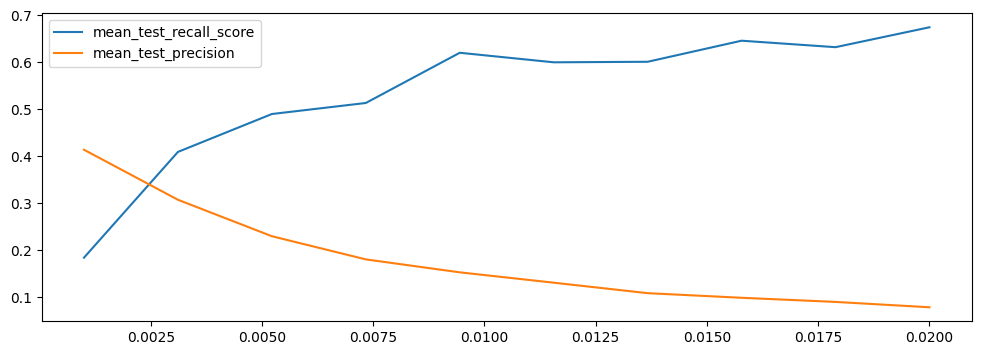

In [68]:
plt.figure(figsize=(12,4))
df1 = pd.DataFrame(grid.cv_results_)

for score in ['mean_test_recall_score', 'mean_test_precision']:
    plt.plot(
        df1["param_contamination"],
        df1[score],
        label = score
    )
plt.legend()

In [71]:
# plt.figure(figsize=(12,4))
# df1 = pd.DataFrame(grid.cv_results_)

# for score in ['mean_train_recall_score', 'mean_train_precision']:
#     plt.scatter(
#         x = [_[1] for _ in df1['param_class_weight']],
#         y = df1[score.replace('test', 'train')],
#         label = score
#     )
# plt.legend()

# for Logistic Regression

In [73]:
def min_recall_precision_score(y_true, y_pred):
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    return min(recall, precision)

make_scorer(min_recall_precision_score, greater_is_better=False)
?make_scorer

Signature:
make_scorer(
    score_func,
    *,
    response_method='default',
    greater_is_better=True,
    **kwargs,
)
Docstring:
Make a scorer from a performance metric or loss function.

A scorer is a wrapper around an arbitrary metric or loss function that is called
with the signature `scorer(estimator, X, y_true, **kwargs)`.

It is accepted in all scikit-learn estimators or functions allowing a `scoring`
parameter.

The parameter `response_method` allows to specify which method of the estimator
should be used to feed the scoring/loss function.

Read more in the :ref:`User Guide <scoring_callable>`.

Parameters
----------
score_func : callable
    Score function (or loss function) with signature
    ``score_func(y, y_pred, **kwargs)``.

response_method : {"predict_proba", "decision_function", "predict"} or             list/tuple of such str, default=None

    Specifies the response method to use get prediction from an estimator
    (i.e. :term:`predict_proba`, :term:`decision_fun